# Animations to demonstrate the effect of learning rate on neural network training

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import cm

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data: y = 2x + 3 + noise
x = np.linspace(0, 1, 100)
y_true = 2 * x + 3
y = y_true + np.random.normal(scale=0.1, size=len(x))

# Learning rates to demonstrate (too low, optimal, too high)
learning_rates = [0.01, 0.1, 0.4]
num_epochs = 50
initial_w, initial_b = 0.0, 0.0  # Initial parameters

# Prepare loss landscape grid
w_grid = np.linspace(0, 4, 100)
b_grid = np.linspace(1, 5, 100)
W, B = np.meshgrid(w_grid, b_grid)
loss_grid = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_pred = W[i, j] * x + B[i, j]
        loss_grid[i, j] = np.mean((y_pred - y) ** 2)

# Train models and store histories
histories = []
for lr in learning_rates:
    w, b = initial_w, initial_b
    history = {'ws': [], 'bs': [], 'losses': []}
    for epoch in range(num_epochs):
        # Forward pass and loss calculation
        y_pred = w * x + b
        loss = np.mean((y_pred - y) ** 2)
        history['ws'].append(w)
        history['bs'].append(b)
        history['losses'].append(loss)

        # Gradient calculation
        dw = 2 * np.mean((y_pred - y) * x)
        db = 2 * np.mean(y_pred - y)

        # Update parameters
        w -= lr * dw
        b -= lr * db
    histories.append(history)

# Create figure and axes
fig, axes = plt.subplots(3, 2, figsize=(12, 14), dpi=100)
fig.suptitle('Effect of Learning Rate on Neural Network Training', fontsize=16, fontweight='bold')
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Initialize artists storage
all_artists = []
annotation_boxes = []

# Setup each row for a learning rate
for i, lr in enumerate(learning_rates):
    # Left plot: Data and regression line
    ax_left = axes[i, 0]
    ax_left.scatter(x, y, c='blue', alpha=0.7, label='Data')
    ax_left.plot(x, y_true, 'g--', lw=2, label='True Line')
    ax_left.set_xlim(0, 1)
    ax_left.set_ylim(2.5, 5.5)
    ax_left.set_title(f'Learning Rate: {lr}', fontsize=13)
    ax_left.set_xlabel('Input Feature (x)')
    ax_left.set_ylabel('Target (y)')
    ax_left.grid(alpha=0.3)
    reg_line, = ax_left.plot([], [], 'r-', lw=2, label='Current Model')

    # Right plot: Loss landscape and trajectory
    ax_right = axes[i, 1]
    contour = ax_right.contourf(W, B, loss_grid, levels=30, cmap=cm.viridis, alpha=0.6)
    fig.colorbar(contour, ax=ax_right, shrink=0.8)
    ax_right.plot(2, 3, 'y*', markersize=15, label='Optimal Parameters')
    ax_right.set_xlim(0, 4)
    ax_right.set_ylim(1, 5)
    ax_right.set_title(f'Parameter Space (w and b)', fontsize=13)
    ax_right.set_xlabel('Weight (w)')
    ax_right.set_ylabel('Bias (b)')
    ax_right.grid(alpha=0.3)
    trajectory, = ax_right.plot([], [], 'b-', lw=1.5, label='Trajectory')
    current_point, = ax_right.plot([], [], 'ro', markersize=7, label='Current Position')

    # Annotation box for epoch and loss
    text_box = ax_right.text(0.02, 0.05, '', transform=ax_right.transAxes,
                            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # Store artists
    all_artists.append({
        'reg_line': reg_line,
        'trajectory': trajectory,
        'current_point': current_point,
        'text_box': text_box
    })

    # Add legends
    ax_left.legend(loc='upper left')
    ax_right.legend(loc='upper right')

# Animation update function
def update(epoch):
    updated_artists = []
    for i, lr in enumerate(learning_rates):
        history = histories[i]
        w = history['ws'][epoch]
        b = history['bs'][epoch]
        loss = history['losses'][epoch]

        # Update regression line
        y_pred = w * x + b
        all_artists[i]['reg_line'].set_data(x, y_pred)

        # Update trajectory and current point
        trajectory_x = history['ws'][:epoch+1]
        trajectory_y = history['bs'][:epoch+1]
        all_artists[i]['trajectory'].set_data(trajectory_x, trajectory_y)
        all_artists[i]['current_point'].set_data([w], [b])

        # Update text box
        text_content = f'Epoch: {epoch+1}/{num_epochs}\nLoss: {loss:.4f}\nw: {w:.2f}, b: {b:.2f}'
        all_artists[i]['text_box'].set_text(text_content)

        # Collect artists to update
        updated_artists.extend([
            all_artists[i]['reg_line'],
            all_artists[i]['trajectory'],
            all_artists[i]['current_point'],
            all_artists[i]['text_box']
        ])
    return updated_artists

# Initialize animation
def init():
    updated_artists = []
    for i in range(len(learning_rates)):
        all_artists[i]['reg_line'].set_data([], [])
        all_artists[i]['trajectory'].set_data([], [])
        all_artists[i]['current_point'].set_data([], [])
        all_artists[i]['text_box'].set_text('')
        updated_artists.extend([
            all_artists[i]['reg_line'],
            all_artists[i]['trajectory'],
            all_artists[i]['current_point'],
            all_artists[i]['text_box']
        ])
    return updated_artists

# Create animation
ani = FuncAnimation(
    fig,
    update,
    frames=num_epochs,
    init_func=init,
    blit=True,
    interval=300,  # ms between frames
    repeat_delay=3000  # ms before replay
)

# Save and display
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for suptitle
ani.save('learning_rate_animation.gif', writer='pillow', dpi=120)
plt.close()
print("Animation saved as 'learning_rate_animation.gif'")

Animation saved as 'learning_rate_animation.gif'


In [ ]:
https://github.com/RooCodeInc

To create an educational Python animation demonstrating the learning rate parameter in neural networks, I'll use Matplotlib for visualization and NumPy for computations. This animation will visualize how different learning rates affect gradient descent optimization in a simple linear regression scenario, making it ideal for teaching fundamental concepts.


### Key Educational Features

1. **Comparative Visualization**:
   - **Three learning rate scenarios**: Too low (0.01), optimal (0.1), and too high (0.4)
   - Dual plots per scenario showing both data space and parameter space
   - Color-coded loss landscape with trajectory paths

2. **Dynamic Elements**:
   - Real-time regression line updating in data space
   - Parameter trajectory visualization in loss landscape
   - Current position marker and epoch/loss annotations
   - Smooth animation at 300ms/frame for easy observation

3. **Pedagogical Design**:
   - True relationship (green dashed line) as reference
   - Star marker at optimal parameters (w=2, b=3)
   - Text boxes showing current parameters and loss
   - Color gradients indicating loss intensity (dark = low loss)

### Interpretation of Results
1. **Low Learning Rate (0.01)**:
   - Slow convergence with small steps in parameter space
   - Fails to reach optimum within epochs (incomplete learning)

2. **Optimal Learning Rate (0.1)**:
   - Steady, direct convergence to optimal parameters
   - Smooth loss reduction without oscillations

3. **High Learning Rate (0.4)**:
   - Overshooting and oscillations in parameter space
   - Divergent behavior causing unstable training

### Requirements
- Python 3.7+
- Libraries: `numpy`, `matplotlib`
- Runs in 15-20 seconds (saves GIF automatically)

This animation demonstrates core concepts from search results: learning rate's impact on convergence , loss landscape navigation , and the balance between speed and stability . The visual approach aligns with educational principles from neural network literature .

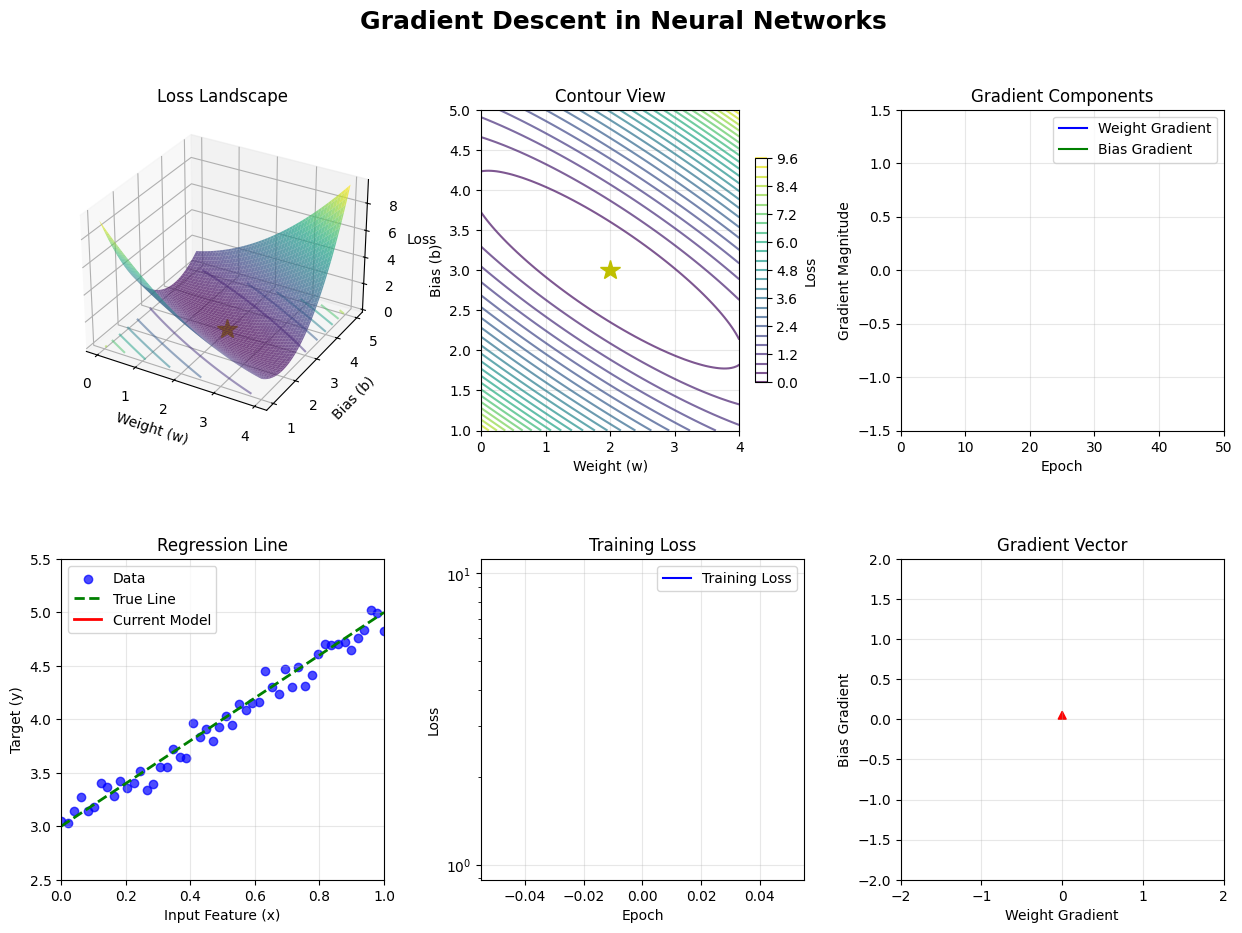

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import cm
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# Create figure with subplots
fig = plt.figure(figsize=(15, 10), dpi=100)
fig.suptitle('Gradient Descent in Neural Networks', fontsize=18, fontweight='bold')

# 3D Loss Landscape
ax1 = fig.add_subplot(231, projection='3d')
ax1.set_title('Loss Landscape', fontsize=12)
ax1.set_xlabel('Weight (w)')
ax1.set_ylabel('Bias (b)')
ax1.set_zlabel('Loss')
ax1.view_init(elev=30, azim=-60)

# 2D Contour Plot
ax2 = fig.add_subplot(232)
ax2.set_title('Contour View', fontsize=12)
ax2.set_xlabel('Weight (w)')
ax2.set_ylabel('Bias (b)')
ax2.grid(alpha=0.3)

# Gradient Visualization
ax3 = fig.add_subplot(233)
ax3.set_title('Gradient Components', fontsize=12)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Gradient Magnitude')
ax3.grid(alpha=0.3)
ax3.set_xlim(0, 50)
ax3.set_ylim(-1.5, 1.5)

# Regression Line
ax4 = fig.add_subplot(234)
ax4.set_title('Regression Line', fontsize=12)
ax4.set_xlabel('Input Feature (x)')
ax4.set_ylabel('Target (y)')
ax4.grid(alpha=0.3)

# Loss Curve
ax5 = fig.add_subplot(235)
ax5.set_title('Training Loss', fontsize=12)
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Loss')
ax5.grid(alpha=0.3)
ax5.set_yscale('log')

# Gradient Vector
ax6 = fig.add_subplot(236)
ax6.set_title('Gradient Vector', fontsize=12)
ax6.set_xlabel('Weight Gradient')
ax6.set_ylabel('Bias Gradient')
ax6.grid(alpha=0.3)
ax6.set_xlim(-2, 2)
ax6.set_ylim(-2, 2)

plt.subplots_adjust(wspace=0.3, hspace=0.4)

# Generate synthetic data
x = np.linspace(0, 1, 50)
y_true = 2 * x + 3
y = y_true + np.random.normal(scale=0.1, size=len(x))

# Create loss landscape
w_grid = np.linspace(0, 4, 100)
b_grid = np.linspace(1, 5, 100)
W, B = np.meshgrid(w_grid, b_grid)
loss_grid = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_pred = W[i, j] * x + B[i, j]
        loss_grid[i, j] = np.mean((y_pred - y) ** 2)

# Plot loss landscape in 3D
ax1.plot_surface(W, B, loss_grid, cmap=cm.viridis, alpha=0.7)
ax1.contour(W, B, loss_grid, zdir='z', offset=0, cmap=cm.viridis, alpha=0.5)

# Plot contour view
contour = ax2.contour(W, B, loss_grid, levels=30, cmap=cm.viridis, alpha=0.7)
fig.colorbar(contour, ax=ax2, shrink=0.7, label='Loss')

# Plot data and initial regression line
ax4.scatter(x, y, c='blue', alpha=0.7, label='Data')
ax4.plot(x, y_true, 'g--', lw=2, label='True Line')
ax4.set_xlim(0, 1)
ax4.set_ylim(2.5, 5.5)
reg_line, = ax4.plot([], [], 'r-', lw=2, label='Current Model')
ax4.legend(loc='upper left')

# Training parameters
learning_rate = 0.2
num_epochs = 50
initial_w, initial_b = 0.0, 0.0

# Store training history
history = {'ws': [], 'bs': [], 'losses': [], 'grad_w': [], 'grad_b': []}

# Initialize artists
trajectory_3d, = ax1.plot([], [], [], 'r-', lw=1.5, label='Path')
current_point_3d, = ax1.plot([], [], [], 'ro', markersize=6)
trajectory_2d, = ax2.plot([], [], 'r-', lw=1.5)
current_point_2d, = ax2.plot([], [], 'ro', markersize=6)
grad_w_line, = ax3.plot([], [], 'b-', label='Weight Gradient')
grad_b_line, = ax3.plot([], [], 'g-', label='Bias Gradient')
loss_curve, = ax5.plot([], [], 'b-', label='Training Loss')
grad_vector, = ax6.plot([], [], 'b-')
grad_arrow = ax6.arrow(0, 0, 0, 0, head_width=0.1, head_length=0.1, fc='r', ec='r')
grad_magnitude = ax3.text(0.05, 0.95, '', transform=ax3.transAxes,
                          bbox=dict(facecolor='white', alpha=0.8))
current_loss_text = ax5.text(0.05, 0.95, '', transform=ax5.transAxes,
                            bbox=dict(facecolor='white', alpha=0.8))

# Add legends
ax3.legend(loc='upper right')
ax5.legend(loc='upper right')

# Add optimal point marker
ax1.plot([2], [3], [0], 'y*', markersize=15, label='Optimal Point')
ax2.plot(2, 3, 'y*', markersize=15, label='Optimal Point')

# Train the model
w, b = initial_w, initial_b
for epoch in range(num_epochs):
    # Forward pass
    y_pred = w * x + b
    loss = np.mean((y_pred - y) ** 2)

    # Store history
    history['ws'].append(w)
    history['bs'].append(b)
    history['losses'].append(loss)

    # Compute gradients
    dw = 2 * np.mean((y_pred - y) * x)
    db = 2 * np.mean(y_pred - y)

    history['grad_w'].append(dw)
    history['grad_b'].append(db)

    # Update parameters
    w -= learning_rate * dw
    b -= learning_rate * db

# Animation update function
def update(epoch):
    # Update 3D plot
    traj_x = history['ws'][:epoch+1]
    traj_y = history['bs'][:epoch+1]
    traj_z = history['losses'][:epoch+1]
    traj_z = [max(0, z) for z in traj_z]  # Ensure non-negative for plotting

    trajectory_3d.set_data(traj_x, traj_y)
    trajectory_3d.set_3d_properties(traj_z)
    current_point_3d.set_data([history['ws'][epoch]], [history['bs'][epoch]])
    current_point_3d.set_3d_properties([history['losses'][epoch]])

    # Update 2D contour
    traj_2d_x = history['ws'][:epoch+1]
    traj_2d_y = history['bs'][:epoch+1]
    trajectory_2d.set_data(traj_2d_x, traj_2d_y)
    current_point_2d.set_data([history['ws'][epoch]], [history['bs'][epoch]])

    # Update gradient visualization
    grad_w_line.set_data(range(epoch+1), history['grad_w'][:epoch+1])
    grad_b_line.set_data(range(epoch+1), history['grad_b'][:epoch+1])

    # Update loss curve
    loss_curve.set_data(range(epoch+1), history['losses'][:epoch+1])
    current_loss_text.set_text(f"Loss: {history['losses'][epoch]:.4f}")

    # Update gradient vector
    grad_vector.set_data([history['grad_w'][epoch]], [history['grad_b'][epoch]])
    grad_arrow.set_positions((0, 0), (history['grad_w'][epoch], history['grad_b'][epoch]))
    return [
        trajectory_3d, current_point_3d,
        trajectory_2d, current_point_2d,
        grad_w_line, grad_b_line,
        loss_curve, grad_vector, grad_arrow
    ]

In [31]:
def init():
    # Reset 3D trajectory and current point
    trajectory_3d.set_data([], [])
    trajectory_3d.set_3d_properties([])
    current_point_3d.set_data([], [])
    current_point_3d.set_3d_properties([])

    # Reset 2D trajectory and current point
    trajectory_2d.set_data([], [])
    current_point_2d.set_data([], [])

    # Reset gradient visualization
    grad_w_line.set_data([], [])
    grad_b_line.set_data([], [])

    # Reset loss curve
    loss_curve.set_data([], [])
    current_loss_text.set_text("")

    # Reset gradient vector
    grad_vector.set_data([], [])
    grad_arrow.set_positions((0, 0), (0, 0))
    return [
        trajectory_3d, current_point_3d,
        trajectory_2d, current_point_2d,
        grad_w_line, grad_b_line,
        loss_curve, grad_vector, grad_arrow
    ]

In [32]:
from matplotlib.patches import FancyArrowPatch

# Create the arrow (replace previous grad_arrow)
grad_arrow = FancyArrowPatch((0, 0), (0, 0), mutation_scale=15, color='r')
ax6.add_patch(grad_arrow)


In [33]:
from matplotlib.animation import FuncAnimation

ani = FuncAnimation(
    fig,
    update,
    frames=num_epochs,
    init_func=init,
    blit=True,
    interval=300
)

ani.save('learning_rate_animation_2.gif', writer='pillow', dpi=120)

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from torch.optim import SGD, Adam, Adagrad, RMSprop

def plot_optimizer_comparison():
    # Create synthetic loss landscape
    x = np.linspace(-5, 5, 100)
    y = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(X) * np.cos(Y) + 0.1*(X**2 + Y**2)  # Example loss surface

    # Initialize optimizers at same starting point
    start_point = torch.tensor([-4.0, -4.0], requires_grad=True)
    optimizers = {
        'SGD': SGD([start_point], lr=0.1),
        'Momentum': SGD([start_point], lr=0.1, momentum=0.9),
        'Adam': Adam([start_point], lr=0.1),
        'RMSprop': RMSprop([start_point], lr=0.1)
    }

    # Store paths for each optimizer
    paths = {name: [] for name in optimizers}

    # Run optimization
    for _ in range(100):
        for name, optimizer in optimizers.items():
            loss = torch.sin(start_point[0]) * torch.cos(start_point[1]) + 0.1*(start_point[0]**2 + start_point[1]**2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            paths[name].append(start_point.detach().numpy().copy())

    # Create animation
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.contourf(X, Y, Z, levels=50, cmap='viridis')

    lines = {name: ax.plot([], [], 'o-', label=name)[0] for name in optimizers}

    def init():
        for line in lines.values():
            line.set_data([], [])
        return list(lines.values())

    def update(frame):
        for name, line in lines.items():
            x_data = [p[0] for p in paths[name][:frame]]
            y_data = [p[1] for p in paths[name][:frame]]
            line.set_data(x_data, y_data)
        return list(lines.values())

    ani = FuncAnimation(fig, update, frames=100, init_func=init,
                       blit=True, interval=100)
    plt.legend()
    plt.title('Optimizer Comparison on Synthetic Loss Landscape')
    ani.save('optimizer_comparison.gif', writer='pillow', dpi=100)
    plt.close()

plot_optimizer_comparison()